In [1]:
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [5]:
def wrangle(filepath):
  df = pd.read_csv(filepath)
  df_fear = df[df["TURNFEAR"] == 1]
  return df_fear

In [7]:
df = wrangle("/content/drive/MyDrive/SCFP2019.csv")
print("Dataframe Shape",df.shape)
df.head()

Dataframe Shape (4623, 351)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
5,2,21,3790.476607,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
6,2,22,3798.868505,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,3,2,2
7,2,23,3799.468393,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
8,2,24,3788.076005,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
9,2,25,3793.066589,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2


In [8]:
# Create Feature Matrix
X = df[["DEBT","HOUSES"]]

print(f"Feature Matrix Shape {X.shape}")

X.head()

Feature Matrix Shape (4623, 2)


,DEBT,HOUSES
5,12200.0,0.0
6,12600.0,0.0
7,15300.0,0.0
8,14100.0,0.0
9,15400.0,0.0


In [9]:
assert df.shape[0] > 0, "DataFrame should not be empty after filtering."
assert X.shape[1] == 2, (
    f"Feature matrix should have 2 columns, got {X.shape[1]}."
)
assert list(X.columns) == ["DEBT", "HOUSES"], (
    f"Expected columns ['DEBT', 'HOUSES'], got {list(X.columns)}."
)
assert X.isna().sum().sum() == 0, (
    "Feature matrix should have no missing values."
)
print("All checks passed!")
print(f"Working with {X.shape[0]} households and {X.shape[1]} features.")

All checks passed!
Working with 4623 households and 2 features.


# Exploratory Visualization

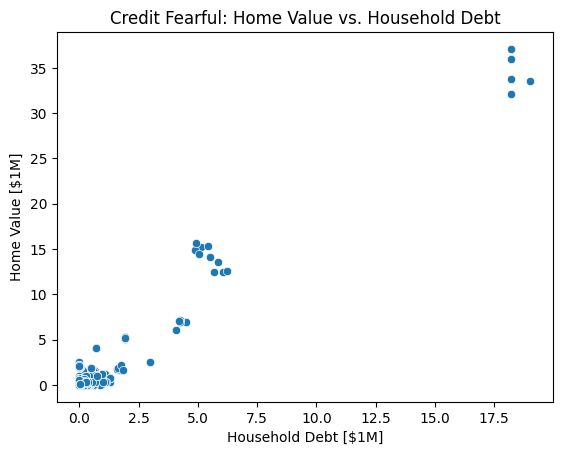

In [13]:
sns.scatterplot(x=df["DEBT"]/1e6, y=df["HOUSES"]/1e6)
plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt")
plt.show()

# Building K-Means Cluster

In [12]:
model =KMeans(n_clusters=3, random_state=42)

model.fit(X)

KMeans(n_clusters=3, random_state=42)

In [14]:
labels = model.labels_

print(f"FIRST 10 LABELS: {labels[:10]}")

FIRST 10 LABELS: [0 0 0 0 0 0 0 0 0 0]


In [15]:
# Extract Centroids
centroids = model.cluster_centers_

print(f"Centroids Shape {centroids.shape}")
print(f"Centroids Values \n{centroids}")

Centroids Shape (3, 2)
Centroids Values 
[[   91017.57766674   116150.29328698]
 [18384100.         34484000.        ]
 [ 5065800.         11666666.66666667]]


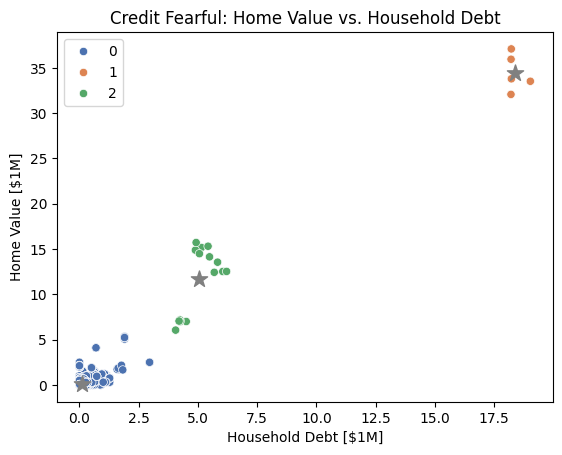

In [17]:
sns.scatterplot(
    x=df["DEBT"] / 1e6, y=df["HOUSES"] / 1e6, hue=labels, palette="deep"
)

plt.scatter(
    centroids[:, 0] / 1e6, centroids[:, 1] / 1e6,
    color="gray", marker="*", s=150
)
plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt");

# Evaluating Cluster Quality

In [18]:
inertia = model.inertia_
ss = silhouette_score(X, labels)

print(f"Inertia: {inertia}")
print(f"Silhouette Score: {ss}")

Inertia: 939554010797059.4
Silhouette Score: 0.9768842462944348


In [23]:
n_clusters = range(2,13)
inertia_errors = []
silhouette_scores = []

for k in n_clusters:
  temp_model = KMeans(n_clusters=k, random_state=42)
  temp_model.fit(X)

  inertia_errors.append(temp_model.inertia_)

  score = silhouette_score(X, temp_model.labels_)

  silhouette_scores.append(score)



print(f"Inertia Errors: {inertia_errors}")
print(f"Silhouette Scores: {silhouette_scores}")

Inertia Errors: [3018038313336857.5, 939554010797059.4, 546098841715646.25, 312953826439188.7, 259345573699051.2, 190276466219404.72, 182823496442980.5, 137854230409642.14, 101281028664355.22, 94456305764354.53, 82784036332859.89]
Silhouette Scores: [np.float64(0.9855099957519555), np.float64(0.9768842462944348), np.float64(0.9490311483406091), np.float64(0.8145735206135484), np.float64(0.8098677144717595), np.float64(0.7283895532760676), np.float64(0.7292682050725934), np.float64(0.7303424143073027), np.float64(0.733219368089596), np.float64(0.7338888149535772), np.float64(0.7323568183281238)]


# Elbow Hunt

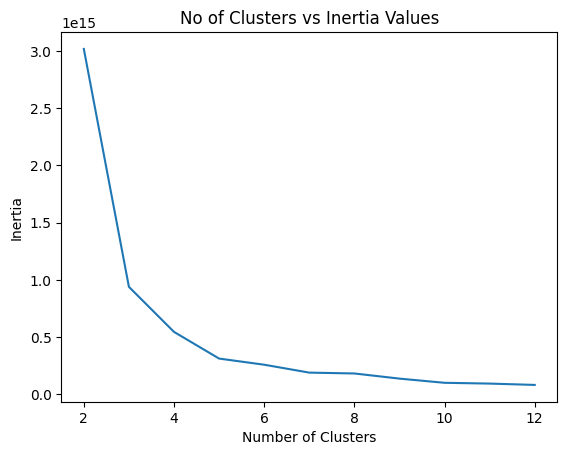

In [28]:
plt.plot(n_clusters, inertia_errors)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("No of Clusters vs Inertia Values")
plt.show()

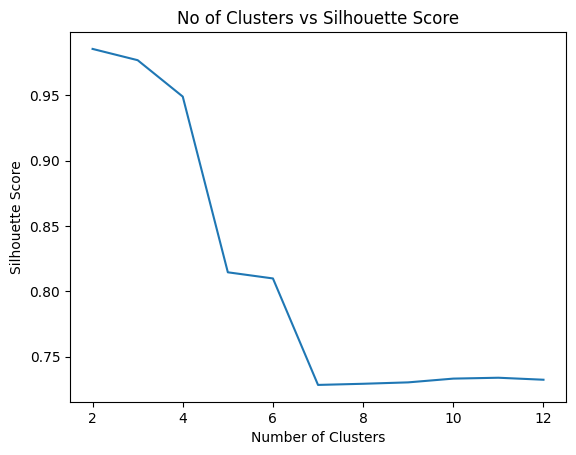

In [27]:
plt.plot(n_clusters, silhouette_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("No of Clusters vs Silhouette Score")
plt.show()

# Final Model And Interpretation

In [29]:
final_model = KMeans(n_clusters=4, random_state=42)

final_model.fit(X)


KMeans(n_clusters=4, random_state=42)

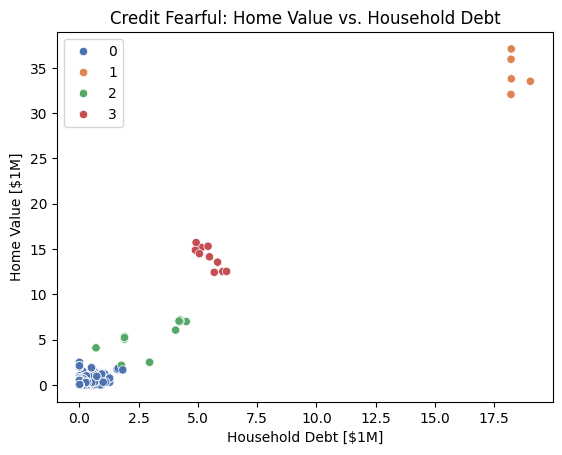

In [30]:
sns.scatterplot(
    x=df["DEBT"] / 1e6, y=df["HOUSES"] / 1e6,
    hue=final_model.labels_, palette="deep"
)
plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt");

# Final Insight

In [31]:
xgb = X.groupby(final_model.labels_).mean()
xgb

,DEBT,HOUSES
0,8.488629e+04,1.031872e+05
1,1.838410e+07,3.448400e+07
2,2.420929e+06,4.551429e+06
3,5.472800e+06,1.407400e+07


In [34]:
import plotly.express as px


fig = px.bar(
    xgb / 1e6,
    barmode="group",
    title="Mean Home Value & Household Debt by Cluster",
    labels={
        "index": "Cluster",
        "value": "Value [$1 million]",
        "variable": "Financial Metric"
    }
)


fig.show()